## Celda 1: Importación y Carga

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.manifold import TSNE
from sklearn.metrics import silhouette_score

sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams['figure.figsize'] = (10, 6)

import os
if not os.path.exists('outputs/01_processed_data.npz'):
    raise FileNotFoundError('Primero debes ejecutar el archivo 01_analisis... para generar los datos.')

# Cargar datos desde el archivo generado por el Notebook 01
data = np.load('outputs/01_processed_data.npz')
X_scaled = data['X_scaled']
y = data['y']
print(f"📊 Dimensiones cargadas: X_scaled {X_scaled.shape}, y {y.shape}")
print("Librerías importadas. Datos de 'fact_competencia' listos.")

📊 Dimensiones cargadas: X_scaled (1200, 179), y (1200,)
Librerías importadas. Datos de 'fact_competencia' listos.


## Celda 1.5: Verificación de Clases (Binario vs Multiclase)
Esta celda analiza automáticamente la variable objetivo (`y`) para demostrar al equipo de ingeniería si el modelo se adaptará a un problema Binario o Multiclase.

In [ ]:
import numpy as np

clases_unicas = np.unique(y)
num_clases = len(clases_unicas)

print("📊 ANÁLISIS DE LA VARIABLE OBJETIVO (Target 'y'):")
print(f"   • Clases únicas detectadas: {clases_unicas}")
print(f"   • Cantidad de clases: {num_clases}")

if num_clases == 2:
    print("   ➔ TIPO DE PROBLEMA: Clasificación BINARIA 🟢🔴")
    print("   (La red neuronal usará 1 neurona de salida con activación Sigmoide)")
elif num_clases > 2:
    print("   ➔ TIPO DE PROBLEMA: Clasificación MULTICLASE 🟡🟢🔴")
    print(f"   (La red neuronal usará {num_clases} neuronas de salida con activación Softmax)")
else:
    print("   ➔ ERROR: Muy pocas clases detectadas.")

📊 ANÁLISIS DE LA VARIABLE OBJETIVO (Target 'y'):
   • Clases únicas detectadas: [0 1 2]
   • Cantidad de clases: 3
   ➔ TIPO DE PROBLEMA: Clasificación MULTICLASE 🟡🟢🔴
   (La red neuronal usará 3 neuronas de salida con activación Softmax)


## Celda 2: Reducción con PCA

In [ ]:
print(f"Dimensiones de entrada (crudo): {X_scaled.shape}")
pca = PCA(n_components=0.95, random_state=42)
X_pca = pca.fit_transform(X_scaled)
print(f"Dimensiones de salida (comprimido): {X_pca.shape}")
print(f"Componentes retenidos: {pca.n_components_}")

Dimensiones de entrada (crudo): (1200, 179)
Dimensiones de salida (comprimido): (1200, 84)
Componentes retenidos: 84


## Celda 3: Visualización de Varianza de los Datos

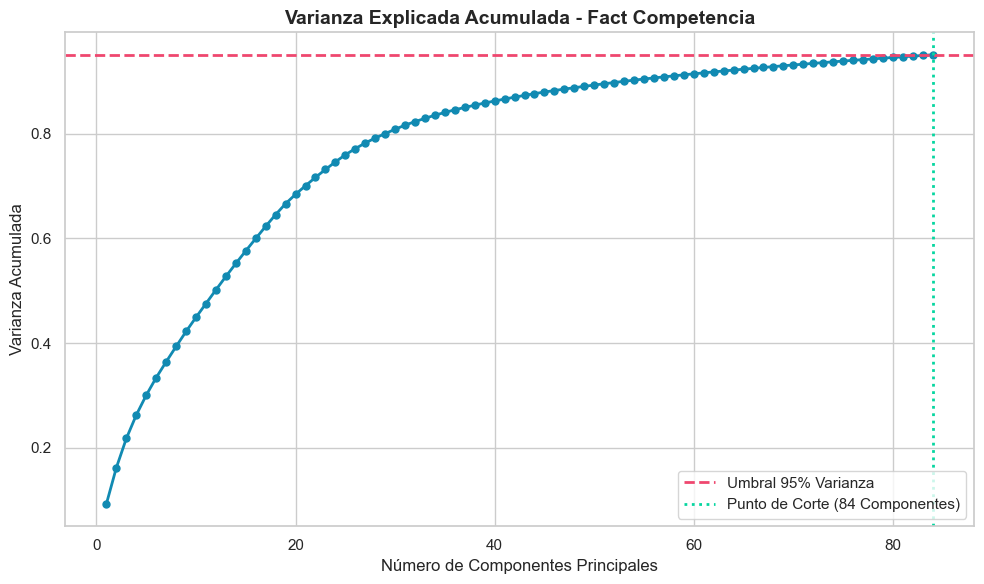

In [ ]:
plt.figure(figsize=(10, 6))
varianza_acumulada = np.cumsum(pca.explained_variance_ratio_)

plt.plot(range(1, len(varianza_acumulada) + 1), varianza_acumulada, 
         marker='o', linestyle='-', color='#118AB2', linewidth=2, markersize=5)

plt.axhline(y=0.95, color='#EF476F', linestyle='--', linewidth=2, label='Umbral 95% Varianza')
plt.axvline(x=pca.n_components_, color='#06D6A0', linestyle=':', linewidth=2, 
            label=f'Punto de Corte ({pca.n_components_} Componentes)')

plt.title('Varianza Explicada Acumulada - Fact Competencia', fontsize=14, fontweight='bold')
plt.xlabel('Número de Componentes Principales')
plt.ylabel('Varianza Acumulada')
plt.legend(loc='lower right', frameon=True)
plt.tight_layout()
plt.show()

## Celda 4: Visualización t-SNE y Silhouette

Proyectando t-SNE...


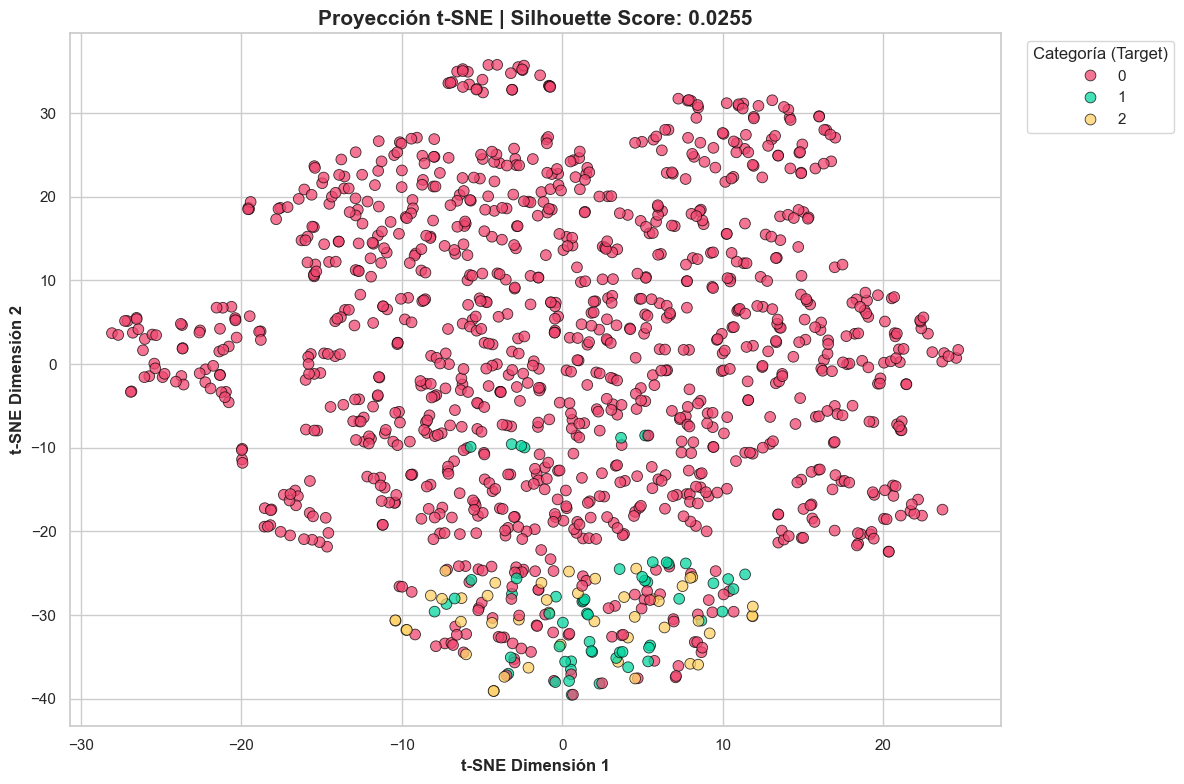

In [ ]:
print("Proyectando t-SNE...")
tsne = TSNE(n_components=2, perplexity=30, max_iter=300, init='pca', learning_rate='auto', random_state=42)
X_tsne = tsne.fit_transform(X_pca)
score_silueta = silhouette_score(X_pca, y)

plt.figure(figsize=(12, 8))
sns.scatterplot(x=X_tsne[:, 0], y=X_tsne[:, 1], hue=y, 
                palette=['#EF476F', '#06D6A0', '#FFD166'], alpha=0.75, edgecolor='black', s=60)

plt.title(f'Proyección t-SNE | Silhouette Score: {score_silueta:.4f}', fontsize=15, fontweight='bold')
plt.xlabel('t-SNE Dimensión 1', fontweight='bold')
plt.ylabel('t-SNE Dimensión 2', fontweight='bold')
plt.legend(title='Categoría (Target)', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

## Celda 5: Interpretación y Selección de Clasificador
### 📖 Guía de Interpretación del Gráfico t-SNE
- **Islas Definidas**: Representan agrupaciones inherentes en los datos (ej. por proveedor o categoría). El modelo aprendió la estructura matemática subyacente.
- **Mezcla de Colores**: Si en una misma "isla" los colores están mezclados, indica que la frontera de decisión entre las clases es altamente difusa y dependiente de relaciones complejas, imposibles de separar con una simple línea recta.

In [ ]:
print("="*80)
if score_silueta < 0.3:
    print("CONCLUSIÓN: Solapamiento severo. Los datos son altamente complejos y no lineales.")
    print("Un clasificador normal (Regresión Logística / Árboles de Decisión) fallará.")
    print("🎯 ACCIÓN: Se requiere una RED NEURONAL.")
else:
    print("CONCLUSIÓN: Clases separables.")
    print("🎯 ACCIÓN: Es viable probar primero con un clasificador tradicional y ligero antes de pasar a Deep Learning.")
print("="*80)

CONCLUSIÓN: Solapamiento severo. Los datos son altamente complejos y no lineales.
Un clasificador normal (Regresión Logística / Árboles de Decisión) fallará.
🎯 ACCIÓN: Se requiere una RED NEURONAL.


## Celda 6: Exportación para el Modelo

In [ ]:
output_file = 'fact_competencia_pca_ready.npz'
np.savez(output_file, X=X_pca, y=y)
print(f"✅ Pipeline completado. Dataset de Competencia exportado a: {output_file}")

✅ Pipeline completado. Dataset de Competencia exportado a: fact_competencia_pca_ready.npz
